In [57]:
# -*- coding: utf-8 -*-
"""
Created on Thu Jul 16 16:46:47 2026

@author: Nieme101
"""

# from ae_picker import aic_picker, plot_channels, read_unfiltered
from labseis import tpc5
import h5py as h5py
# import tpc5 as tpc5
import numpy as np
#!/usr/bin/env python3
"""
AE 1D fault localization pipeline
Geometry:
- Fault length: 300 mm
- Sensor plane offset from fault: 50 mm
- Array radius: 40 mm
- Center at fault position 150 mm
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import rfft, irfft
from scipy.ndimage import uniform_filter1d

# ---------------- Configuration ---------------- #
FS = 1000000.0  # Hz
VP = 2730    # m/s
FAULT_LENGTH_MM = 300.0
FAULT_CENTER_MM = 150.0 #- Location of central sensor relative to left side
OFFSET_MM = 26.0 # - Distance of central sensor to fault plane - radius of circle (24.5 mm) if circle at edge of fault block 
RADIUS_MM = 10.0 # Distance of other sensors from central sensor

FILTER_LOW = 50000.0
FILTER_HIGH = 450000.0

STA = int(0.002 * FS)
LTA = int(0.05 * FS)
TRIGGER = 10.0

PRE = int(0.1 * FS)
POST = int(0.1 * FS)

SENSORS_MM = np.array([
    [OFFSET_MM, FAULT_CENTER_MM],           # center
    [OFFSET_MM - RADIUS_MM, FAULT_CENTER_MM],  # top  
    [OFFSET_MM + RADIUS_MM, FAULT_CENTER_MM],  # bottom 
    [OFFSET_MM, FAULT_CENTER_MM + RADIUS_MM],  # right
    [OFFSET_MM, FAULT_CENTER_MM - RADIUS_MM],  # left
]) / 1000.0
# ------------- User data loading ------------- #

In [58]:
import os
data_path = r'/Volumes/DirectShear/Activelocation_left_100bursts.tpc5'
if os.path.exists(data_path):
    f = h5py.File(data_path, 'r')
else:
    print('Data file not found; make sure the path is correct and the file exists.')

# block=1 continous data

# Metadata: Timestamp and sampling rate
RecTimeString = tpc5.getStartTime(f,channel=1,block=1)
RecTimeList   = RecTimeString.split('T',1)
RecDate       = RecTimeList[0]
TimeList      = RecTimeList[1].split('.',1)
RecTime       = TimeList[0]
TriggerSample = tpc5.getTriggerSample(f,channel=1,block=1)
SamplingRate  = tpc5.getSampleRate(f,channel=1,block=1)


In [59]:
# Create list of channels
print('Now preparing the list of AE triggers')
channel_list = []
i = 1
while True:
    try:
        channel = tpc5.getChannelName(f, channel=i)
        channel_list.append(channel)
#        print('Read block', i)
        i = i + 1
    except:
        print('List of triggers... ready')
        break
print('Number of channels:', i)
print(channel_list)

Now preparing the list of AE triggers
List of triggers... ready
Number of channels: 7
['Array1 (0.A1)', 'Array2 (0.A2)', 'Array3 (0.A3)', 'Array4 (0.A4)', 'Array5 (0.B1)', 'Source (0.B2)']


In [60]:
# find how many blocks are in the file using hy5py
num_blocks = tpc5.getNumBlocks(f, channel=1)
print('Number of blocks in the file:', num_blocks)

Number of blocks in the file: 100


In [61]:
def wiggles(xt, t_axis, offset, ax=None, scalebar=True, scale=0.5, scale_range='trace'):
    ''''
    Plot a set of traces as wiggle plots.
    Parameters:
    - xt: 2D array of shape (num_traces, num_samples)
    - t_axis: 1D array of time values corresponding to the samples
    - offset: 1D array of offsets for each trace
    - ax: Matplotlib axis object to plot on (optional)
    - scalebar: Boolean indicating whether to plot a scale bar (default: True)
    - scale: Scale factor for the amplitude of the traces (default: 0.5)
    - scale_range: 'trace' to normalize each trace individually, 'global' to normalize all traces together (default: 'trace')'''
    
    if ax==None:
        fig, ax = plt.subplots(figsize=(10, 5))
    normalized = np.max(xt)
    if scale_range=='trace':
        normalized = np.max(xt, axis=-1)
    for i in range(xt.shape[0]):
        ax.plot(t_axis, scale*xt[i]/normalized[i] + offset[i])
    if scalebar:
        for i in range(xt.shape[0]):
            ax.plot([t_axis[0],t_axis[0]], [offset[i],offset[i]+scale], 'k')
            ax.annotate('{}'.format(normalized[i]), xy=[0,offset[i]+0.1])
    return fig, ax

def read_tpc5(f, block, starting_channel=1, num_channels=5, start_time=0, end_time=None):
    '''
    Read TPC5 data from a given block and channel range.
    Parameters:
    - f: h5py.File object
    - block: Block number to read from
    - starting_channel: The first channel to read (1-indexed)
    - num_channels: Number of channels to read
    - start_time: Start time in milliseconds (default: 0)
    - end_time: End time in milliseconds (default: None, read until the end)
    Returns:
    - AE: Array of shape (num_channels, num_samples) containing the voltage data
    - t: Time axis in milliseconds
    - timestamp: Timestamp of the first sample in seconds
    '''
    if f is None:
        # generate synthetic data for testing
        length = int(FS * 0.01)  # 10 ms of data
        t = np.arange(length) / FS
        AE = np.random.randn(num_channels, length)
        return AE, t, 0.0
    fs = tpc5.getSampleRate(f, channel=1, block=block)
    start_sample = int(start_time * fs / 1000)
    if end_time is None:
        end_sample = None
    else:
        end_sample = int(end_time * fs / 1000)
    tmp = tpc5.getVloltageDataLimited(f,channel=starting_channel,block=block, start_sample=start_sample, end_sample=end_sample)

    t = 1000*np.arange(len(tmp))/fs # time axis in ms

    timestamp = tpc5.getTriggerTime(f,channel=1,block=block) + (start_sample/fs) # timestamp in seconds

    AE = np.empty([num_channels,len(tmp)])
    AE[0] = tmp

    for i in range(1,num_channels):
        AE[i] = tpc5.getVloltageDataLimited(f,channel=i+starting_channel,block=block, start_sample=start_sample, end_sample=end_sample)
    
    return AE, t, timestamp

In [62]:
tmp, t, timestamp = read_tpc5(f, starting_channel=1, num_channels=6, block=5)


In [63]:
# load all blocks and apply stack to produce a single AE signal for each channel
AE = np.stack([read_tpc5(f, starting_channel=1, num_channels=6, block=b)[0] for b in range(1, num_blocks + 1)])
# average over blocks
AE_stacked = np.mean(AE, axis=0)
print('number of AE traces: ', AE_stacked.shape[0])
print('length of AE traces: ', AE_stacked.shape[1])

number of AE traces:  6
length of AE traces:  1024


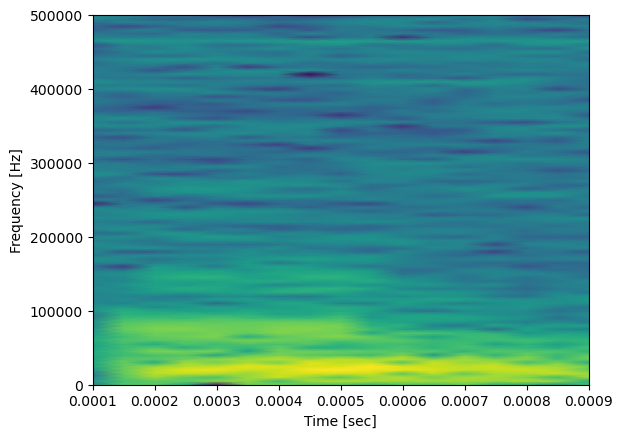

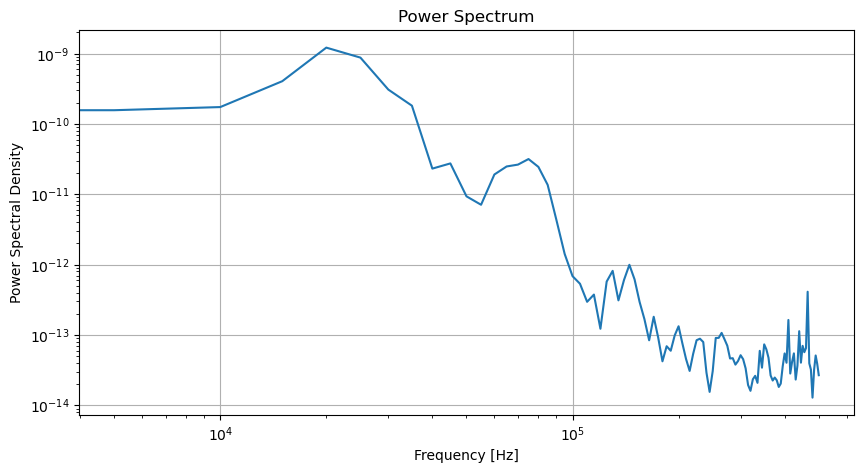

In [64]:
# calcualte spectrogram with a sliding window of 0.05 ms
from labseis.signal import spectrogram
freq, t_spec, Sxx = spectrogram(AE_stacked[0], fs=SamplingRate, plot=True, nperseg=200, noverlap=150)

#calculate power spectrum and plot it
power_spectrum = np.mean(Sxx, axis=1)
plt.figure(figsize=(10, 5))
plt.loglog(freq, power_spectrum)
plt.ylabel('Power Spectral Density')
plt.xlabel('Frequency [Hz]')
plt.title('Power Spectrum')
plt.grid(True)


In [67]:
from labseis.signal import bandpass
import scipy as sp
# first apply a taper the AE before bandpass filtering
ns = len(AE_stacked[0])
tukeytaper = sp.signal.windows.tukey(ns, alpha=0.1, sym=True)
AE_stacked = AE_stacked*tukeytaper
AE_stacked_filtered = bandpass(AE_stacked, 1/SamplingRate, 55000.0, 200000.0)

Text(0.5, 1.0, 'time after:5.613333 s, experiment: PSM111, block: 1')

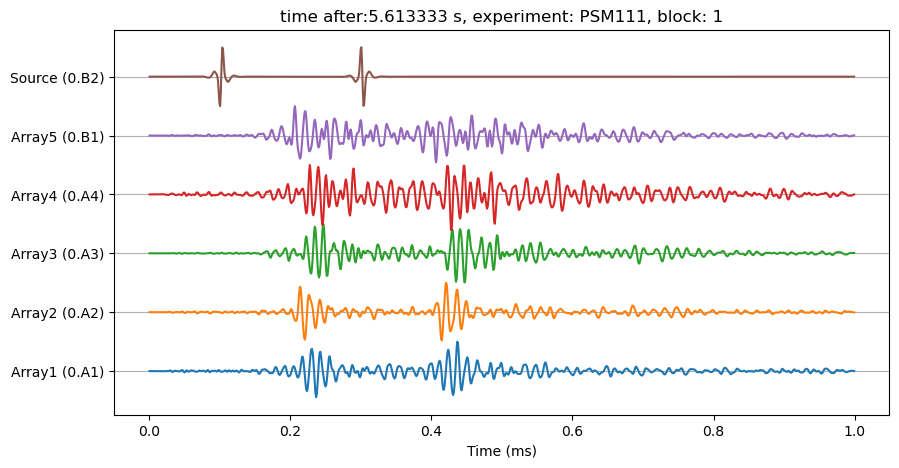

In [68]:
idx_t = (t>0)&(t<1)
fig, ax = wiggles(AE_stacked_filtered[:,idx_t], t[idx_t], np.arange(6), scale=0.5, scalebar=False)
ax.grid(axis='y')
ax.set_yticks(np.arange(6))
ax.set_yticklabels(channel_list[:6])
ax.set_xlabel('Time (ms)')
plt.title(f'time after:{timestamp} s, experiment: PSM111, block: 1')

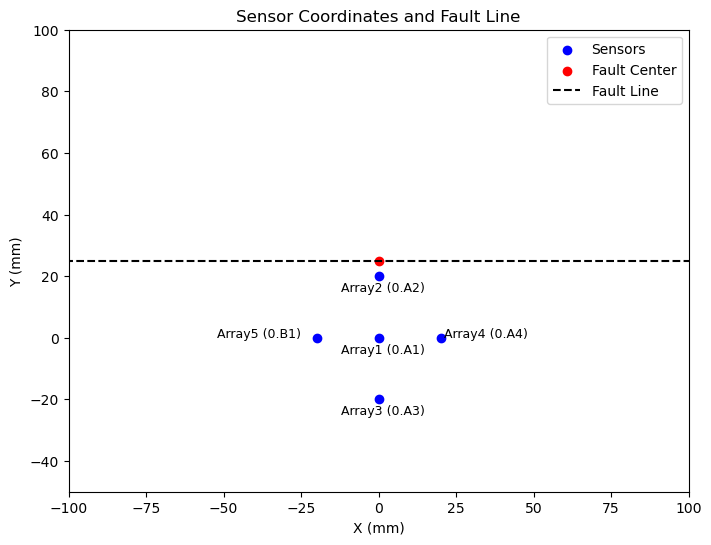

In [48]:
# set coordinate of the sensors in mm
# x along the fault
# y perpendicular to the fault
# z fault plane depth

sensor_coordinates = np.array([
    [0, 0, 0],
    [0, 20, 0],
    [0, -20, 0],
    [20, 0, 0],
    [-20, 0, 0],
])

fault_center_coordinates = np.array([0, 25, 0])  # center of the fault in mm

# Plot the sensor coordinates and fault line, add sensor names on the plot
plt.figure(figsize=(8, 6))
plt.scatter(sensor_coordinates[:, 0], sensor_coordinates[:, 1], c='blue', label='Sensors')
plt.text(sensor_coordinates[0, 0]+15, sensor_coordinates[0, 1]-5, channel_list[0], fontsize=9, ha='right')
plt.text(sensor_coordinates[1, 0]+15, sensor_coordinates[1, 1]-5, channel_list[1], fontsize=9, ha='right')
plt.text(sensor_coordinates[2, 0]+15, sensor_coordinates[2, 1]-5, channel_list[2], fontsize=9, ha='right')
plt.text(sensor_coordinates[3, 0]+28, sensor_coordinates[3, 1], channel_list[3], fontsize=9, ha='right')
plt.text(sensor_coordinates[4, 0]-5, sensor_coordinates[4, 1], channel_list[4], fontsize=9, ha='right')
# plt.text(sensor_coordinates[5, 0]+15, sensor_coordinates[5, 1]-5, channel_list[5] if len(channel_list)>5 else 'Ch6', fontsize=9, ha='right')

plt.scatter(fault_center_coordinates[0], fault_center_coordinates[1], c='red', label='Fault Center')
plt.plot([fault_center_coordinates[0] - 150, fault_center_coordinates[0] + 150], [fault_center_coordinates[1], fault_center_coordinates[1]], 'k--', label='Fault Line')  # Fault line
plt.xlim(-100, 100)
plt.ylim(-50, 100)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Sensor Coordinates and Fault Line')
plt.legend()

In [49]:
# ---------------------------------------------------
# Create an xarray Dataset for sensor geometry and names
# ---------------------------------------------------
import xarray as xr

# Convert sensor coordinates from mm to metres for consistency
sensor_coords_m = sensor_coordinates / 1000.0

# Build the Dataset: dimension = sensor, coordinates = x, y, z
sensor_ds = xr.Dataset({
    "x": ("sensor", sensor_coords_m[:,0]),
    "y": ("sensor", sensor_coords_m[:,1]),
    "z": ("sensor", sensor_coords_m[:,2]),
})

# Add channel names as a coordinate (optional)
sensor_ds = sensor_ds.assign_coords({"sensor": np.arange(sensor_coords_m.shape[0]), "channel_name": ("sensor", channel_list[:5])})

# Now sensor_ds can be used for geometry (e.g., sensor_ds[['x','y','z']].values)


In [50]:
# ---------------------------------------------------
# Placeholder: xarray dataset creation moved to after sensor definition
# ---------------------------------------------------
# (This cell was moved to a later position to ensure sensor_coordinates is defined)

In [51]:
# Debug sensor coordinates content
print('sensor_coordinates:')
print(sensor_coordinates)
print(channel_list)

sensor_coordinates:
[[  0   0   0]
 [  0  20   0]
 [  0 -20   0]
 [ 20   0   0]
 [-20   0   0]]
['Array1 (0.A1)', 'Array2 (0.A2)', 'Array3 (0.A3)', 'Array4 (0.A4)', 'Array5 (0.B1)', 'Source (0.B2)']


In [52]:
# densify the data signal sampling rate to 
# ---------------------------------------------------
# Interpolate data to higher sampling rate (100 MHz) using spline
# ---------------------------------------------------
from scipy.interpolate import interp1d
# Original sampling rate FS (Hz) is 1e6
original_fs = FS
# Desired sampling rate 100 MHz
new_fs = 100e6
# Time axis for original data (in seconds) for each channel
# AE_stacked_filtered shape (6, L)
L = AE_stacked_filtered.shape[1]
t_original = np.arange(L) / original_fs  # seconds
# Create interpolated array for first 5 channels
num_interp_channels = 5
AE_interp = np.empty((num_interp_channels, int(np.ceil(L * new_fs / original_fs))))
for ch in range(num_interp_channels):
    f_interp = interp1d(t_original, AE_stacked_filtered[ch], kind='cubic', fill_value='extrapolate')
    t_new = np.arange(AE_interp.shape[1]) / new_fs
    AE_interp[ch] = f_interp(t_new)
# Update FS variable to new sampling rate for subsequent processing
# Store new time axis for later plotting if needed
t_interp = np.arange(AE_interp.shape[1]) / new_fs

# Prepare data for migration (slice of interpolated data)
data_for_migration = AE_interp[:5, 10000:60000]  # shape (5, L_new)
# normalize the data for migration
data_for_migration = data_for_migration / np.max(np.abs(data_for_migration), axis=1, keepdims=True)
# calculate envelope of the data for migration
from scipy.signal import hilbert
data_for_migration = np.abs(hilbert(data_for_migration, axis=1))
t_data = t_interp[10000:60000]
# ---------------------------------------------------
# Store the interpolated AE data in an xarray Dataset
# ---------------------------------------------------
import xarray as xr

# AE_interp has shape (num_channels, num_samples) for the first 5 channels
# t_interp is the time axis (seconds) for the interpolated data

data_xr = xr.Dataset({
    "waveform": ( ("sensor", "time"), data_for_migration )
}, coords={
    "sensor": np.arange(data_for_migration.shape[0]),
    "time": t_data
})

# Add channel names as a coordinate (optional)
data_xr = data_xr.assign_coords({"channel_name": ("sensor", channel_list[:data_for_migration.shape[0]])})

# Now data_xr can be used for analysis, e.g.,
# print(data_xr)

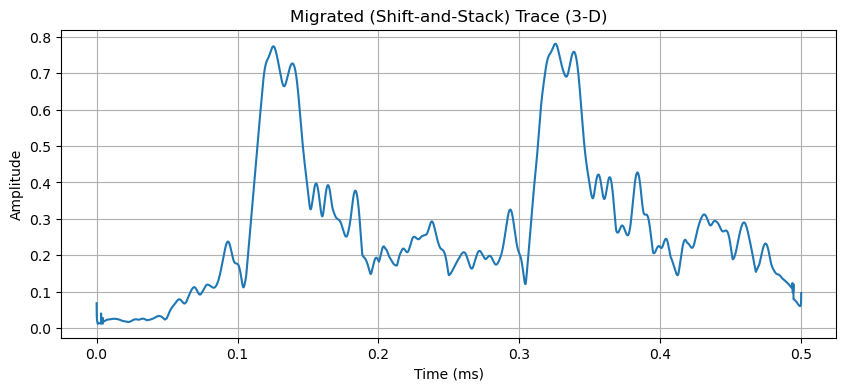

In [70]:
from labseis.utils_directshear import migrate_shift_stack_3d

# ---------------------------------------------------
# Prepare geometry for migration (homogeneous velocity)
# ---------------------------------------------------

# Receiver coordinates: use full 3‑D sensor positions (in metres)
rec_coords = sensor_coordinates[:5, :] / 1000.0  # shape (5, 3)

# Discretize fault line in the x‑y‑z space (y fixed at 25 mm, z = 0)
fault_length_m = FAULT_LENGTH_MM / 1000.0
num_fault_points = 61  # e.g., 1 cm spacing
x_fault = np.linspace(-fault_length_m/2, fault_length_m/2, num_fault_points)
y_fault = np.full_like(x_fault, fault_center_coordinates[1] / 1000.0)  # 25 mm → 0.025 m
z_fault = np.zeros_like(x_fault)  # surface (z = 0)
fault_pts = np.column_stack((x_fault, y_fault, z_fault))

# Run migration (shift‑and‑stack) using the 3‑D geometry
# Use interpolated data for first 5 channels
stacked_best, stacked_per_source, shifts = migrate_shift_stack_3d(data_for_migration, rec_coords, fault_pts, VP, new_fs, ref_channel=0)
stacked_trace = stacked_best

# Plot the migrated trace
plt.figure(figsize=(10, 4))
t_mig = np.arange(stacked_trace.size) / new_fs * 1000  # ms
plt.plot(t_mig, stacked_trace)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('Migrated (Shift‑and‑Stack) Trace (3‑D)')
plt.grid(True)
plt.show()

# Optional: visualize shift matrix heatmap (energy per source point)
# Compute energy per source point (same as inside function)
energy = np.sum(stacked_per_source ** 2, axis=1)  # compute actual energy

In [71]:
# Receiver coordinates: use full 3‑D sensor positions from the xarray Dataset (in metres)
# Extract x, y, z arrays and stack them into an (M, 3) numpy array
rec_coords = np.column_stack((sensor_ds['x'].values, sensor_ds['y'].values, sensor_ds['z'].values))[:5]
rec_coords

array([[ 0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.02,  0.  ],
       [ 0.  , -0.02,  0.  ],
       [ 0.02,  0.  ,  0.  ],
       [-0.02,  0.  ,  0.  ]])

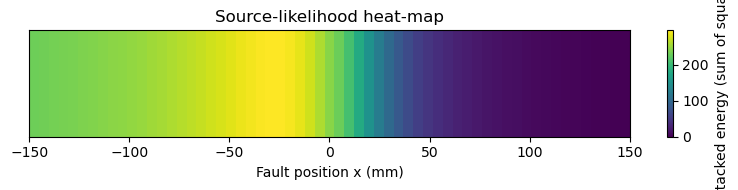

[-0.03   0.025  0.   ]


In [72]:
# ---------------------------------------------------
# 6️⃣  Visualise source‑likelihood heat‑map using computed energy
# ---------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Re‑run migration to obtain stacked_per_source and shifts (in case they are not in the current namespace)
stacked_best, stacked_per_source, shifts = migrate_shift_stack_3d(data_for_migration, rec_coords, fault_pts, VP, new_fs, ref_channel=0)
energy = np.sum(stacked_per_source ** 2, axis=1)  # compute actual energy

# Plot heat‑map (1‑D fault line → colour strip) using the energy computed during migration
extent = [fault_pts[:,0].min()*1000, fault_pts[:,0].max()*1000, 0, 1]
plt.figure(figsize=(8, 2))
plt.imshow(energy[np.newaxis, :]-np.min(energy[np.newaxis, :]), aspect='auto', cmap='viridis', extent=extent)
plt.colorbar(label='Stacked energy (sum of squares)')
plt.xlabel('Fault position x (mm)')
plt.title('Source‑likelihood heat‑map')
plt.yticks([])  # hide vertical axis for 1‑D image
plt.tight_layout()
plt.show()
best_idx = np.argmax(energy)
print(fault_pts[best_idx])

In [ ]:
# ---------------------------------------------------
# 8️⃣  Inspect computed energy values
# ---------------------------------------------------
print('Energy per source point (sum of squares):')
fault_pts[best_idx], energy[best_idx]

Energy per source point (sum of squares):


(array([-0.035,  0.025,  0.   ]), 7523.741198940123)

In [ ]:
# ---------------------------------------------------
# 9️⃣  Inspect shift matrix and verify variation
# ---------------------------------------------------
print('Shift matrix (samples) for each channel and source point:')
print(shifts)
print('Unique shift values per channel:')
for ch in range(shifts.shape[0]):
    print(f'Channel {ch}:', np.unique(shifts[ch]))

Shift matrix (samples) for each channel and source point:
[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0]
 [ -73  -75  -78  -81  -84  -87  -91  -94  -99 -103 -108 -114 -120 -126
  -134 -143 -152 -163 -176 -190 -207 -227 -251 -280 -316 -361 -418 -489
  -577 -675 -733 -675 -577 -489 -418 -361 -316 -280 -251 -227 -207 -190
  -176 -163 -152 -143 -134 -126 -120 -114 -108 -103  -99  -94  -91  -87
   -84  -81  -78  -75  -73]
 [ 166  172  177  183  190  197  205  213  221  231  241  252  264  278
   292  308  326  345  366  390  416  445  478  513  551  591  631  670
   702  725  733  725  702  670  631  591  551  513  478  445  416  390
   366  345  326  308  292  278  264  252  241  231  221  213  205  197
   190  183  177  172 

Travel times (s) for first source point:
Channel 0: 1.575517e-05 s
Channel 1: 1.295067e-05 s
Channel 2: 2.088233e-05 s
Channel 3: 1.067940e-05 s
Channel 4: 2.213012e-05 s


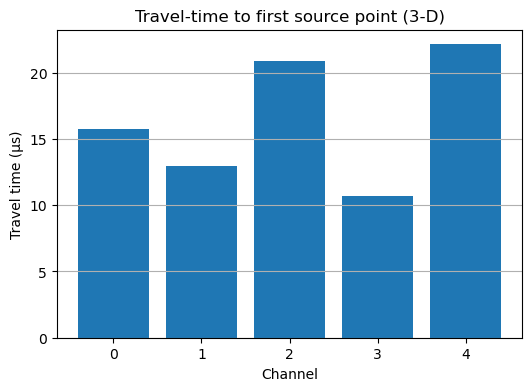

In [ ]:
# ---------------------------------------------------
# Visualise travel‑time table for the first source point (3‑D)
# ---------------------------------------------------
import matplotlib.pyplot as plt

# Compute full 3‑D travel‑time matrix (seconds)
tt = homogeneous_travel_time_3d(fault_pts, rec_coords, VP)

# Travel times for the first source point (index 0) for each channel
tt_first = tt[:, 37]
print('Travel times (s) for first source point:')
for ch, tval in enumerate(tt_first):
    print(f'Channel {ch}: {tval:.6e} s')

# Plot travel times as a bar chart (µs)
plt.figure(figsize=(6, 4))
plt.bar(range(len(tt_first)), tt_first * 1e6)  # convert to µs for readability
plt.xlabel('Channel')
plt.ylabel('Travel time (µs)')
plt.title('Travel‑time to first source point (3‑D)')
plt.grid(True, axis='y')
plt.show()

23
Source point index: 23, x = -35.0 mm
Channel 0 travel time: 15.76 µs
Channel 1 travel time: 12.95 µs
Channel 2 travel time: 20.88 µs
Channel 3 travel time: 22.13 µs
Channel 4 travel time: 10.68 µs


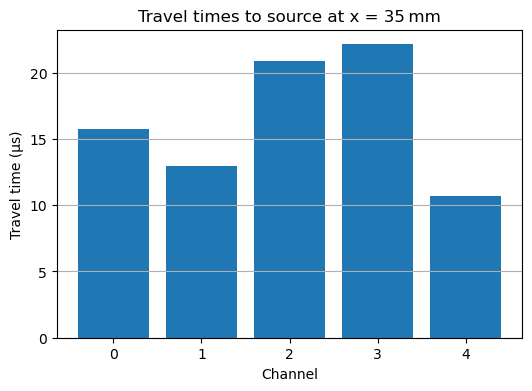

In [ ]:
# ---------------------------------------------------
# Travel times at source position x = 35 mm (y = 25 mm, z = 0)
# ---------------------------------------------------
import numpy as np

# Find the fault point closest to 35 mm (0.035 m)
idx = best_idx
print(idx)
# Compute travel‑time matrix (seconds) for all channels and source points
tt_all = homogeneous_travel_time_3d(fault_pts, rec_coords, VP)
tt_point = tt_all[:, idx]

print(f'Source point index: {idx}, x = {fault_pts[idx,0]*1000:.1f} mm')
for ch, tval in enumerate(tt_point):
    print(f'Channel {ch} travel time: {tval*1e6:.2f} µs')

# Visualise as a bar chart (µs)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(range(len(tt_point)), tt_point*1e6)
plt.xlabel('Channel')
plt.ylabel('Travel time (µs)')
plt.title('Travel times to source at x = 35 mm')
plt.grid(True, axis='y')
plt.show()

In [ ]:
tt[:, idx]

array([1.57551745e-05, 1.29506736e-05, 2.08823338e-05, 2.21301208e-05,
       1.06793991e-05])

In [ ]:
ref_tt = tt[0,idx]
shifts = np.rint((tt[:, idx] - ref_tt) * new_fs).astype(int)
M, L = data_for_migration.shape
aligned = np.empty_like(data_for_migration)
for ch in range(M):
    shift = shifts[ch]
    aligned[ch] = np.roll(data_for_migration[ch], -shift)
    if shift > 0:
        aligned[ch, -shift:] = 0
    elif shift < 0:
        aligned[ch, :-shift] = 0

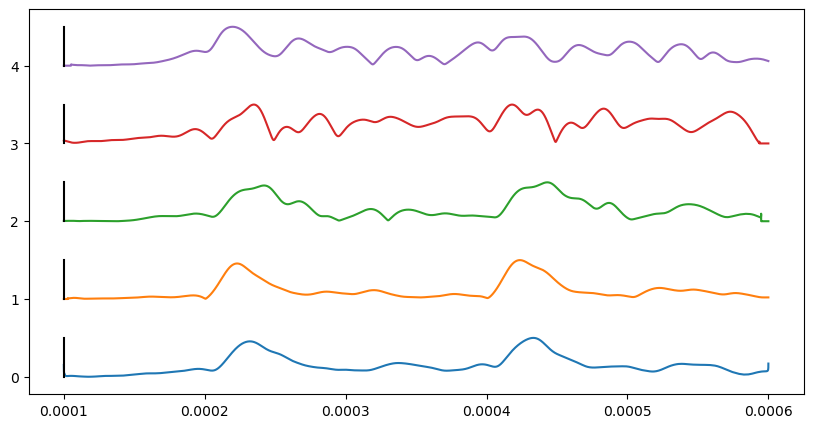

In [ ]:

fig, ax = wiggles(aligned, t_data, np.arange(5), scale=0.5)


In [ ]:
# Debug data stats for each channel
print('AE_stacked_filtered shape:', AE_stacked_filtered.shape)
for ch in range(AE_stacked_filtered.shape[0]):
    print(f'Channel {ch} mean {AE_stacked_filtered[ch].mean():.3e}, std {AE_stacked_filtered[ch].std():.3e}')

AE_stacked_filtered shape: (6, 1024)
Channel 0 mean 9.432e-09, std 7.739e-04
Channel 1 mean -2.712e-08, std 6.885e-04
Channel 2 mean 6.439e-09, std 4.762e-04
Channel 3 mean 1.372e-08, std 4.062e-04
Channel 4 mean 1.016e-08, std 5.198e-04
Channel 5 mean -7.157e-07, std 2.904e-01
